<h1 align="center"><b>Bone Mineral Density Prediction Challenge - Semester 01, 2026</b></h1>
<h2 align="center">CSG2341 Artificial Intelligence 1</h2>
<h3 align="center">Lecturer: Mr. Niroshan Balasuriya</h3>
<h3 align="center">Group: NIR-01</h3>
<h4 align="center">Anuki Senanayakalage (Student ID 10712258)</h4>
<h4 align="center">Disara Ambagala (Student ID 10745176)</h4>
<h4 align="center">Shivangi Sritharan (Student ID 10712234)</h4>
<br>

---
add a real intro/description here i'm lazy

---
<h2><b>Notebook Structure</b></h2>
<table style="display: block; margin-right: auto;">
  <tr><th>#</th><th>Section</th></tr>
  <tr><td>1</td><td><a href="#1---Imports">Imports</a></td></tr>
  <tr><td>2</td><td><a href="#2---File-Paths">File Paths</a></td></tr>
  <tr><td>3</td><td><a href="#3---Load-Metadata">Load Metadata</a></td></tr>
  <tr><td>4</td><td><a href="#4---Organise-Images-into-Folders">Organise Images into Folders</a></td></tr>
  <tr><td>5</td><td><a href="#5---Exploratory-Data-Analysis">Exploratory Data Analysis</a></td></tr>
  <tr><td>6</td><td><a href="#6---Pre-processing-Pipeline">Pre-processing Pipeline</a></td></tr>
  <tr><td>7</td><td><a href="#7---Combine-Image-Features-and-Metadata">Combine Image Features and Metadata</a></td></tr>
  <tr><td>8</td><td><a href="#8---Pipeline-Scaling">Pipeline Scaling</a></td></tr>
  <tr><td>9</td><td><a href="#9---Regression-Evaluation">Regression Evaluation</a></td></tr>
  <tr><td>10</td><td><a href="#10---Diagnostic-Plots">Diagnostic Plots</a></td></tr>
  <tr><td>11</td><td><a href="#11---Convert-Predicted-BMD">Convert Predicted BMD</a></td></tr>
  <tr><td>12</td><td><a href="#12---Evaluation">Evaluation</a></td></tr>
</table>

In [ ]:
# [Shivangi] i'm only keeping this here because i can't figure out where to put it, but i suggest deleting it

# Osteoporosis Detection — Pipeline
# Anuki Kithara
# Date: 28/04/2026
# Models: SVR, KNN, Random Forest

<br>

# 1 - Imports

This section is used to set up the libraries needed to run our notebook.

We first import standard Python modules such as `os` and `pathlib` for file handling. We then import data processing libraries such as `numpy` and `pandas` as well as data visualization libraries such as `matplotlib` to support exploratory data analysis.

For image processing, the code uses `cv2` (OpenCV) along with `skimage` functions such as Histogram of Oriented Gradients (HOG). These are used to extract meaningful features from image data and aid in pre-processing the images.

The machine learning pipeline is built using `scikit-learn`. We import preprocessing tools such as `StandardScaler` and `LabelEncoder`, modules for dimensionality reduction, and modeling with Support Vector Regression. Model selection and evaluation are supported with `GridSearchCV` and `KFold` for cross-validation. Additionally, performance metrics such as MAE, MSE, R², confusion matrix, and classification reports are imported.

Finally, some configuration settings are applied. Warnings are suppressed for cleaner output, and Matplotlib and Seaborn are configured to create visually consistent plots. We also set a fixed random seed to ensure reproducibility across runs.

In [2]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform # for loguniform

# Image I/O and feature extraction
import cv2
from skimage.feature import hog
from skimage.measure import moments_hu, moments_central, moments_normalized, moments

# Modelling
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, balanced_accuracy_score, classification_report
)

#import warnings
#warnings.filterwarnings("ignore")

# Same seed everywhere
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [3]:
%matplotlib inline

<br>

# 2 - File Paths

This section defines all the directory paths and global constants used throughout the notebook.

- `IMAGE_DIR` is the root folder containing all X-ray image data.
- `TRAIN_CSV` and `VAL_CSV` are constants for the train and val CSV files provided with the dataset.
- `TRAIN_IMAGE_DIR` and `VAL_IMAGE_DIR` are the destination folders for images that will be populated in Section 4.
- `IMG_SIZE` - every image is resized to this square resolution before feature extraction.
- `HIST_BINS` is the number of bins used when computing a grayscale intensity histogram.

**Please edit the three paths at the top of the code cell to match your local folder layout before running anything else.**

In [5]:
# ============ Please modify these 3 values according to your folder structure. ============

IMAGE_DIR  = Path("X-rays") # folder path for images
TRAIN_CSV  = Path("train_groundtruth_BMD.csv") # path for the training metadata csv
VAL_CSV    = Path("train_groundtruth_BMD.csv") # path for the validation metadata csv


# This code looks for folders named train_images and val_images and builds them if they don't exist.
TRAIN_IMAGE_DIR = Path("train_images")
VAL_IMAGE_DIR   = Path("val_images")

# Image and feature settings
IMG_SIZE = 128                # resize images to 128x128
HIST_BINS = 64                # grayscale histogram bins

# T-score reference
REF_BMD = 0.86
REF_SD  = 0.12

# Checks if the files exist
assert TRAIN_CSV.exists(), "Training CSV not found"
assert VAL_CSV.exists(), "Validation CSV not found"
assert IMAGE_DIR.exists(), "Image folder not found"

# 3 - Load Metadata

The two CSV files are read into pandas DataFrames.

explain better pls

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)

# Checks dimensions and columns
print(f"Train: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Val:   {val_df.shape[0]} rows, {val_df.shape[1]} columns")
train_df.head()

Train: 377 rows, 4 columns
Val:   54 rows, 4 columns


,image,interview_age,Gender,BMD
0,6.E.1_9021102_20090706_001.png,888,F,0.696443
1,6.E.1_9030718_20090824_001.png,960,F,1.201649
2,6.E.1_9047519_20090720_001.png,876,F,0.945649
3,6.C.1_9048789_20090226_001.png,780,F,0.927137
4,6.E.1_9054972_20090911_001.png,828,F,0.987368


# 4 - Organise Images into Folders

The dataset was provided to us with all the images in one directory named "X-rays". For better visualisation, we decided to separate out the images into dedicated folders based on how they will be used in the pipeline. This section copies each image into a dedicated `train_images/` or `val_images/` subdirectory based on the split recorded in the metadata CSV files.

**Please run this cell ONCE. On subsequent runs, comment out the cell to avoid additional disk operations.**

In [7]:
# Uncomment and run once to organise images into train and val folders
# Then comment this block again.

import shutil

def organise_split(source_dir, dest_dir, df):
    dest_dir.mkdir(exist_ok=True)
    
    for filename in df["image"]:
        src = source_dir / filename
        dst = dest_dir / filename
        
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)


organise_split(IMAGE_DIR, TRAIN_IMAGE_DIR, train_df)
organise_split(IMAGE_DIR, VAL_IMAGE_DIR, val_df)

print("Image folders organised.")

Image folders organised.


# 5 - Exploratory Data Analysis

<h2 style="color: red;">ADD A DESCRIPTION HERE !!!</h2>

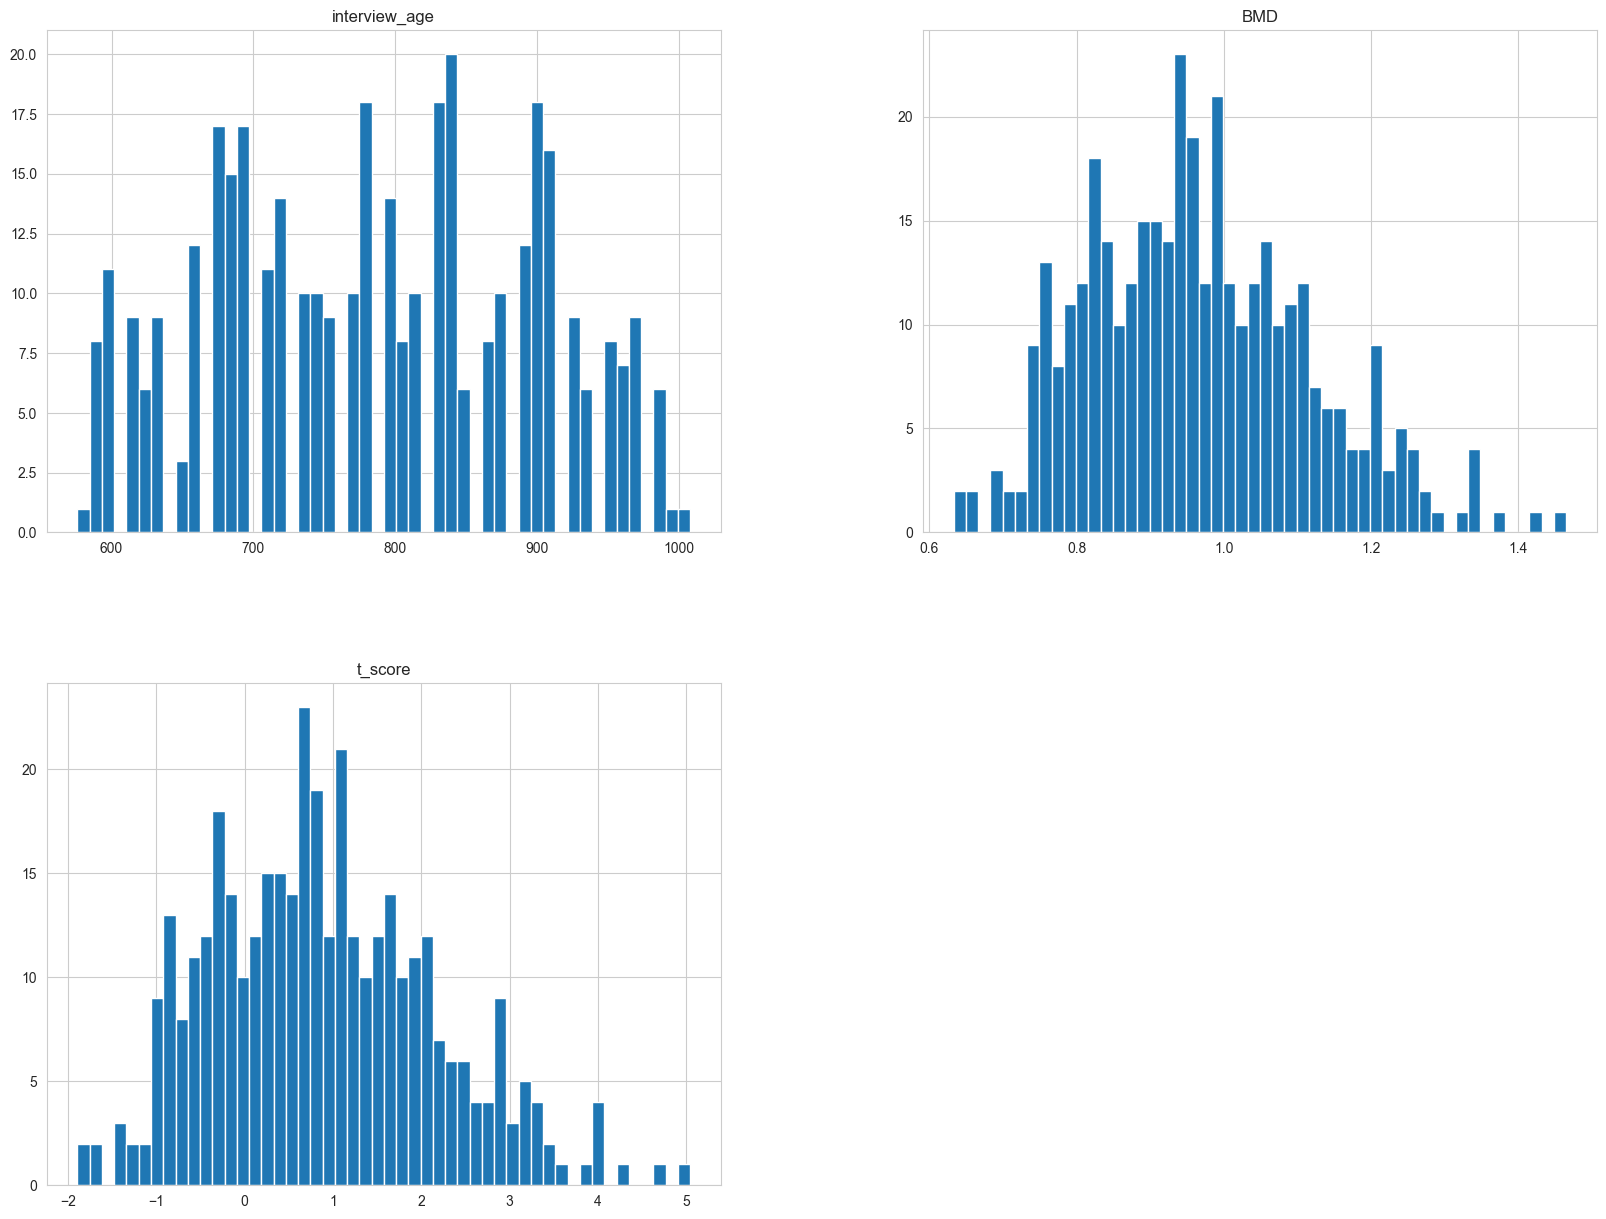

In [12]:
# [Shivangi] I've added some dummy EDA code here. Please update with your code. You can keep mine if you want.
# [Shivangi] Obviously also delete these comments when you update.

# add T-score column
train_df["t_score"], val_df["t_score"] = (train_df["BMD"] - 0.86)/0.12, (val_df["BMD"] - 0.86)/0.12

# add binary label (0 = Normal, 1 = Low BMD)
train_df["low_bmd"], val_df["low_bmd"] = (train_df["t_score"] < -1), (val_df["t_score"] < -1)

train_df.head()

# use Pandas' hist() method to plot the histograms of each numerical column vs number of entries
# you can modify the bins and figsize, and also look up more arguments for the method
train_df.hist(bins=50, figsize=(20,15))

# actually display the plot
plt.show()

<br>

In [ ]:
# [Shivangi] You will need multiple cells to display all of the graphs and images. I suggest running one graphic method per cell.
# [Shivangi] For example, the cell above only shows the output of the Pandas hist() method.
# [Shivangi] This cell builds a new figure with the image data but only shows the output of the Matplotlib show() method.


# display the first 8 training images so we can confirm they loaded correctly

# train_df.head() is the first x rows of the data frame named train_df. 
# head() usually defaults to 5 but we set 8 here
sample_rows = train_df.head(8)

# creates a 2x4 grid of 8 subplots (2 rows, 4 columns)
# and sets the figure size to 14x7
# you can change 2, 4 and the values in figsize (14, 7) to see what happens
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# iterate simultaneously through the grid set up with plt.subplots and the data frame in sample_rows
for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    # create path to the image by combining the training folder name and the name of the image as defined in the csv
    img_path = TRAIN_IMAGE_DIR / row["image"]
    
    if img_path.exists():
        # look for the image defined by img_path
        # you can also look for other arguments to add here, such as cv2.IMREAD_GRAYSCALE (google it lol)
        img = cv2.imread(str(img_path))
        # resize image to the size set in Section 2
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # pair it with a subplot
        # you can also look for other arguments to add here, such as cmap (google it lol)
        ax.imshow(img)
        # give the subplot a title (we just display its BMD value but you can set it to the image name or whatever you'd like)
        ax.set_title(f"BMD={row['BMD']:.3f}", fontsize=9)

    # display this if no image is found. you can display the plot without an if/else loop but if any errors occur it will stop the whole notebook   
    else:
        ax.set_title("Warning: Image not found!", color="red", fontsize=9)

    # hides the grid components. you can comment this out or delete it to see what happens
    ax.axis("off")

# give the plot a title    
plt.suptitle("Sample training X-rays (resized to 128×128)", fontsize=12)

# adjust padding so the subplots automatically fit into the space instead of overflowing or overlapping
# you can remove or comment this out to see what happens.
plt.tight_layout()

# actually display the plot
plt.show()

# 6 - Pre-processing Pipeline

<h2 style="color: red;">PIPELINE IS UNFINISHED !!!</h2>

Each X-ray image is loaded in greyscale, resized to 128x128, and then described using **Histogram of Oriented Gradients (HOG)**.

HOG divides the image into small cells, computes a histogram of edge orientations within each cell, and normalises across overlapping blocks. This captures local texture and edge structure while remaining robust to small changes in lighting.

In [ ]:
def extract_image_features(image_dir: Path, df: pd.DataFrame) -> np.ndarray:
    feature_rows = []
    
    for filename in df["image"]:
        img_path = image_dir / filename

        # load in greyscale
        if img_path.exists():
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            
        # fall back to a blank image if the file is missing
        else:
            print(f"Warning: {filename} not found!")
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

        # resize to a fixed square so every feature vector has the same length
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # actual HOG features
        # pixels_per_cell and cells_per_block were chosen to give ~1000 HOG features at 128×128
        hog_features = hog(
            img,
            orientations=9,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True,
        )

        feature_rows.append(hog_features)  # if adding more, concatenate here
    
    return np.array(feature_rows, dtype=np.float32)
    

Simultaneously, the metadata provided in `train_groundtruth_BMD.csv` is prepared for the model. We first drop the image name and BMD columns, as the former is irrelevant and the latter contains the target values. We then encode the categorical columns into integers. Missing values are filled with a placeholder to avoid the notebook running into fatal errors.

In [ ]:
def prepare_metadata(df: pd.DataFrame) -> np.ndarray:
    # drop image and target columns
    meta = df.drop(columns=["image", "BMD", "t_score", "low_bmd"]).copy()

    # fill with placeholder values if needed
    if meta.empty or meta.shape[1] == 0:
        return np.zeros((len(df), 0), dtype=np.float32)

    for col in meta.columns:
        if col == "Gender":
            # encode gender as integers
            meta[col] = meta[col].map({"M": 0, "F": 1})
            
    return meta.values.astype(np.float32)


def fill_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "category":
            # fill categorical columns with the most frequent value
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            # fill numerical columns with the median
            df[col] = df[col].fillna(df[col].median())

    return df

This cell runs the pre-processing pipeline. `extract_image_features` and `prepare_metadata` are called on both splits to produce the four feature matrices used downstream. Additionally, we print shapes to confirm that:
* the number of rows matches the number of samples in each CSV file.
* feature dimensions are consistent between train and validation

In [ ]:
# run feature extraction

print("Extracting training image features...")
X_img_train = extract_image_features(TRAIN_IMAGE_DIR, train_df)
print(f"  X_img_train shape: {X_img_train.shape}")

print("Extracting validation image features...")
X_img_val   = extract_image_features(VAL_IMAGE_DIR, val_df)
print(f"  X_img_val shape:   {X_img_val.shape}")

print("Preparing training metadata...")
X_meta_train = prepare_metadata(train_df)
print(f"  X_meta_train shape: {X_meta_train.shape}")

print("Preparing validation metadata...")
X_meta_val   = prepare_metadata(val_df)
print(f"  X_meta_val shape:   {X_meta_val.shape}")

print("Feature extraction completed.")

<br>

# 7 - Combine Image Features and Metadata

explain

In [ ]:
X_train = np.hstack([X_img_train, X_meta_train])
X_val   = np.hstack([X_img_val,   X_meta_val])
y_train = train_df["BMD"].values
y_val   = val_df["BMD"].values

print(f"Combined train shape: {X_train.shape}")
print(f"Combined val shape:   {X_val.shape}")
print(f"y_train shape:        {y_train.shape}")

# 8 - Pipeline Scaling

explain

In [ ]:
pipeline = Pipeline([
    # Standardise features
    ("scaler", StandardScaler()),
    # Reduce high-dimensional image features
    ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
    #change this to your own model
    #("model",    SVR()),
    ('model', KNeighborsRegressor())
])

'''
param_grid = {
    "pca__n_components": [30, 50, 75, 100],
    #these are svr specific parameters. swap for your model
    "model__kernel":       ["rbf", "linear"],
    "model__C":            loguniform(0.1, 1000), # samples log uniformly
    "model__epsilon":      loguniform(0.001, 0.05),
    "model__gamma":        ["scale", "auto"],
}'''

param_grid = {
    "pca__n_components": [30, 50, 75, 100],
    "model__n_neighbors": [3, 5, 7, 10, 15],
    "model__weights":     ["uniform", "distance"],
    "model__metric":      ["euclidean", "manhattan"],
    "model__p":           [1, 2],
}

#5 fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

#grid search
#gridSearchCV tries every parameter combination above and chooses the combination with the best cross-validation MAE.
#sklearn uses negative MAE because it maximises scores which we then convert back to positive MAE when printing
search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    verbose=4,
    refit=True,       # after picking best params, refit on full train set
)

#model training
import joblib
with joblib.parallel_backend("threading"):
    search.fit(X_train, y_train)

print("\n=== Best CV result ===")
print(f"Best CV MAE: {-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

# 9 - Regression Evaluation

The best model from the grid search is evaluated on both the training set (to diagnose overfitting) and the held-out validation set (to estimate real-world performance).

<h5 align="center">Reported metrics:</h5>

| Metric | Interpretation |
|---|---|
| **MAE** | Mean absolute error |
| **MSE** | Mean squared error (penalises large errors more heavily) |
| **RMSE** | Square root of MSE |
| **R²** | Proportion of BMD variance explained (1.0 = perfect) |

In [ ]:
best_model = search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_val   = best_model.predict(X_val)

def regression_report(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MSE  = {mse:.6f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  R²   = {r2:.4f}")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_train, y_pred_train, "Training set")
print()
val_metrics   = regression_report(y_val,   y_pred_val,   "Validation set")

# 10 - Diagnostic Plots

explain

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual on validation
axes[0].scatter(y_val, y_pred_val, alpha=0.7, color="steelblue", edgecolor="white")
lo, hi = min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())
axes[0].plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual BMD")
axes[0].set_ylabel("Predicted BMD")
axes[0].set_title("Validation: predicted vs actual")
axes[0].legend()

# Residual plot
residuals = y_val - y_pred_val
axes[1].scatter(y_pred_val, residuals, alpha=0.7, color="darkorange", edgecolor="white")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted BMD")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Validation: residuals")

plt.tight_layout()
plt.show()

# 11 - Convert Predicted BMD

explain

nb: maybe remove this section?

In [ ]:
# Convert predicted BMD into T-scores and binary labels
T_pred_val = (y_pred_val - REF_BMD) / REF_SD
label_pred_val = np.where(T_pred_val >= -1.0, 0, 1)

# True labels already exist from EDA
label_true_val = val_df["low_bmd"].values

results_df = pd.DataFrame({
    "filename": val_df["image"].values,
    "true_BMD": y_val.round(4),
    "pred_BMD": y_pred_val.round(4),
    "true_T": val_df["t_score"].values.round(3),
    "pred_T": T_pred_val.round(3),
    "true_label": label_true_val,
    "pred_label": label_pred_val,
})

results_df.head(15)

# 12 - Evaluation

explain

In [ ]:
#Confusion Matrix

labels_order = ["0", "1"]
cm = confusion_matrix(label_true_val, label_pred_val, labels=labels_order)

# Print confusion matrix
print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=labels_order, columns=labels_order))

# Sensitivity and specificity
TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
specificity = TN / (TN + FP) if (TN + FP) > 0 else float("nan")
bal_acc     = balanced_accuracy_score(label_true_val, label_pred_val)

print(f"\nSensitivity (Low BMD recall):  {sensitivity:.3f}")
print(f"Specificity (Normal recall):   {specificity:.3f}")
print(f"Balanced accuracy:             {bal_acc:.3f}")

print("\nFull classification report:")
print(classification_report(label_true_val, label_pred_val, labels=labels_order, zero_division=0))

# Heatmap visualisation
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Validation confusion matrix")
plt.tight_layout(); plt.show()